# V40: LQ45 AI Strategy - Optimizing for Bull-Dominant Predictions

This notebook modifies the AI training process to be more **Aggressive (Bull-Biased)**. This is achieved by adjusting the objective function to favor Recalling Bull labels over Bear labels.

### Modifications to Increase Bull Predictions:
1. **Class Weighting (`scale_pos_weight`)**: Injected a weight of **1.5** to the Bull class (Target=1). This tells XGBoost that missing a 'Bullish' opportunity is 1.5x more 'expensive' than falsely predicting one.
2. **Beta Adjustment ($F_2$-Score)**: During threshold optimization, we switch from $F_{0.5}$ (Precision-focused) to **$F_2$ (Recall-focused)**. This finds a threshold that captures MORE Bull days, even if some are risky.
3. **Lower Search Range**: The threshold search starts from **0.35** to allow for more inclusive entry signals.

### Core Strategy:
- **Target**: 5-day MA Slope Direction.
- **Execution**: AI Gating + Graph Filter + Markowitz Optimization.
- **Benchmarks**: Markowitz Static & IHSG Proxy.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix, fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. Feature Engineering & Bull-Biased Training ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()
features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

target = (ma5.shift(-1) > ma5).astype(int)
features = features.dropna()
target = target.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)
X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

print("Training Aggressive (Bull-Biased) AI Model...")
# scale_pos_weight=1.5 gives more importance to Bull labels
xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, scale_pos_weight=1.5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Threshold Optimization using F2-Score (Prioritizes Recall/More Bull Predictions)
train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.arange(0.35, 0.70, 0.01)
scores = [fbeta_score(y_train, (train_probs >= t).astype(int), beta=2) for t in thresholds]

opt_t = thresholds[np.argmax(scores)]
print(f"Optimized Aggressive Threshold: {opt_t:.2f} (Targeting MORE Bull signals)")

Training Aggressive (Bull-Biased) AI Model...
Optimized Aggressive Threshold: 0.55 (Targeting MORE Bull signals)


In [3]:
# --- 3. Run Simulation Logic (0.25% Fees) ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i in range(len(returns_window.columns)):
        for j in range(i+1, len(returns_window.columns)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold: G.add_edge(returns_window.columns[i], returns_window.columns[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                   [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(strategy_type, test_dates, returns, ai_probs=None, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    buy_signals = 0
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        if strategy_type == 'AI Aggressive':
            is_risk_off = ai_probs.loc[date] < threshold
            if is_risk_off: weights = {'CASH': 1.0}
            else: 
                weights = optimize_markowitz(window_rets[get_mis_assets(window_rets)])
                buy_signals += 1
        elif strategy_type == 'Markowitz Static':
            if static_weights is None: static_weights = optimize_markowitz(window_rets)
            weights = static_weights
        
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in set(list(weights.keys())+list(prev_weights.keys())))
        val -= (val * turnover * fee)
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[test_dates[i+1], a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(test_dates[i+1]); prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates), buy_signals

Running Bull-Biased AI Simulation...
Total 'Buy' Signals Generated by Aggressive AI: 144 out of 236 days


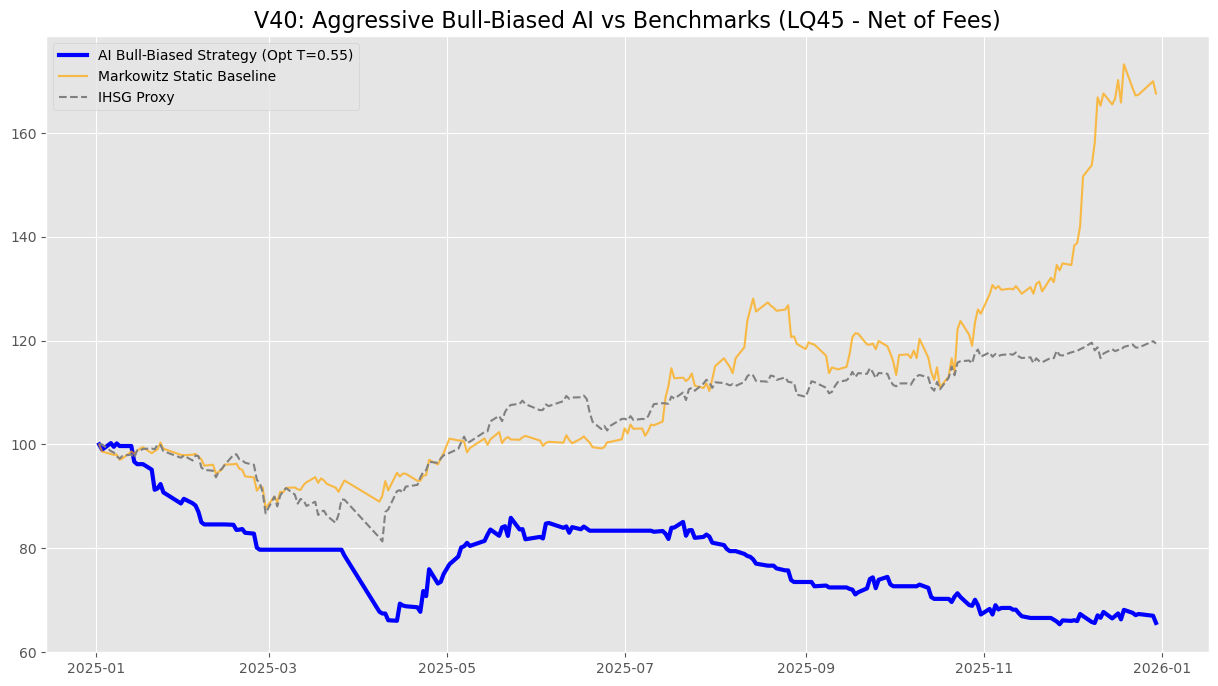

In [4]:
# --- 4. Backtest & Result Comparison ---
test_dates = X_test.index
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=test_dates)

print("Running Bull-Biased AI Simulation...")
res_ai, ai_count = run_simulation('AI Aggressive', test_dates, returns, test_probs, threshold=opt_t)
res_static, _ = run_simulation('Markowitz Static', test_dates, returns)
benchmark = pd.DataFrame({'Portfolio_Value': (market_price.loc[test_dates] / market_price.loc[test_dates[0]] * 100)}, index=test_dates)

print(f"Total 'Buy' Signals Generated by Aggressive AI: {ai_count} out of {len(test_dates)} days")

plt.figure(figsize=(15, 8))
plt.plot(res_ai.index, res_ai['Portfolio_Value'], label=f"AI Bull-Biased Strategy (Opt T={opt_t:.2f})", color='blue', linewidth=3)
plt.plot(res_static.index, res_static['Portfolio_Value'], label="Markowitz Static Baseline", color='orange', alpha=0.7)
plt.plot(benchmark.index, benchmark['Portfolio_Value'], label="IHSG Proxy", linestyle='--', color='gray')
plt.title("V40: Aggressive Bull-Biased AI vs Benchmarks (LQ45 - Net of Fees)", fontsize=16)
plt.legend()
plt.show()